# VELVETFRUIT_EXTRACT — Round 3 Price Analysis

Historical data across days **0, 1, 2**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

DATA_DIR = Path("../historical_data/round_3")
PRODUCT  = "VELVETFRUIT_EXTRACT"

days       = [0, 1, 2]
day_colors = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}
day_labels = {0: "Day 0",   1: "Day 1",   2: "Day 2"}

frames = []
for d in days:
    tmp = pd.read_csv(DATA_DIR / f"prices_round_3_day_{d}.csv", sep=";")
    frames.append(tmp)

raw = pd.concat(frames, ignore_index=True)
df  = raw[raw["product"] == PRODUCT].copy()

ticks_per_day = int(df[df["day"] == 0]["timestamp"].max() + 100)
df["global_ts"] = (df["day"] - days[0]) * ticks_per_day + df["timestamp"]
df = df.sort_values("global_ts").reset_index(drop=True)
df["spread"] = df["ask_price_1"] - df["bid_price_1"]

print(f"Rows: {len(df)}   ticks_per_day: {ticks_per_day}")
df[["day","timestamp","mid_price","bid_price_1","ask_price_1","spread"]].head()


Rows: 30000   ticks_per_day: 1000000


,day,timestamp,mid_price,bid_price_1,ask_price_1,spread
0,0,0,5250.0,5247,5253,6
1,0,100,5250.5,5248,5253,5
2,0,200,5250.5,5248,5253,5
3,0,300,5250.5,5248,5253,5
4,0,400,5250.5,5248,5253,5


## 1 — Mid Price Over Time

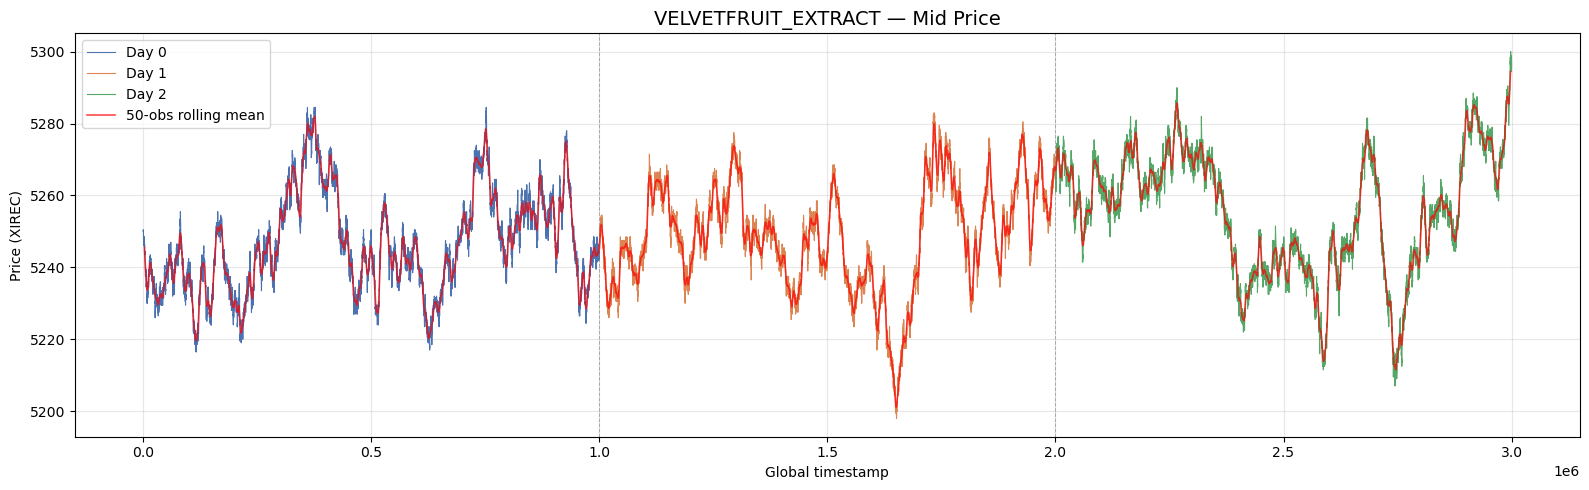

In [2]:
fig, ax = plt.subplots(figsize=(16, 5))
for d in days:
    sub = df[df["day"] == d]
    ax.plot(sub["global_ts"], sub["mid_price"],
            color=day_colors[d], linewidth=0.8, label=day_labels[d])
ts_max = ticks_per_day
for i in range(1, len(days)):
    ax.axvline(i * ts_max, color="grey", linestyle="--", linewidth=0.7, alpha=0.6)
df["mid_rolling"] = df["mid_price"].rolling(50, center=True).mean()
ax.plot(df["global_ts"], df["mid_rolling"],
        color="red", linewidth=1.2, alpha=0.7, label="50-obs rolling mean")
ax.set_title(f"{PRODUCT} — Mid Price", fontsize=14)
ax.set_xlabel("Global timestamp"); ax.set_ylabel("Price (XIREC)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 2 — Bid / Ask Prices & Spread

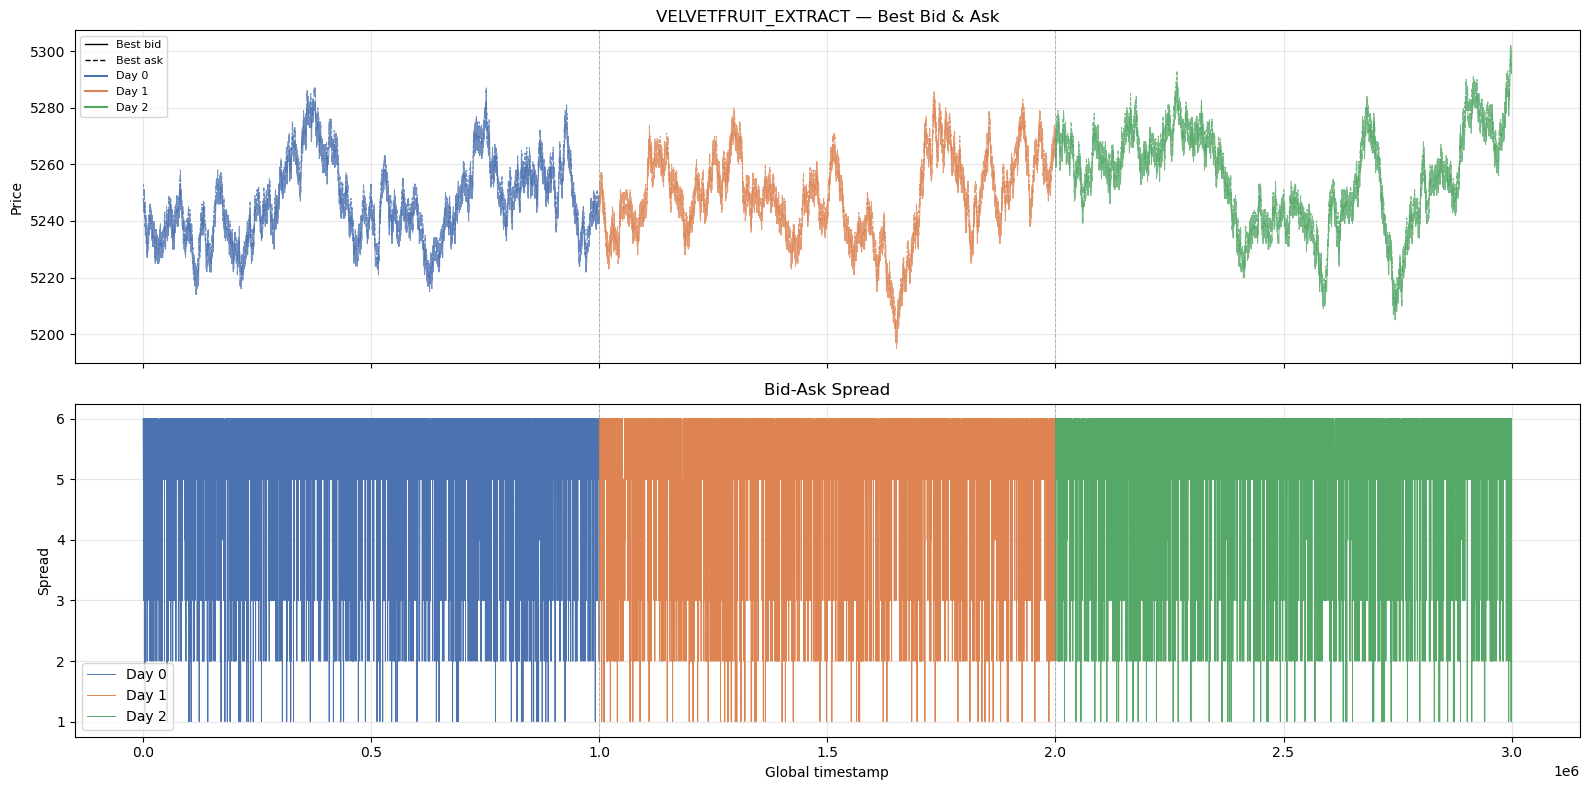

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for d in days:
    sub = df[df["day"] == d]
    ax1.plot(sub["global_ts"], sub["bid_price_1"], color=day_colors[d], lw=0.7, alpha=0.8)
    ax1.plot(sub["global_ts"], sub["ask_price_1"], color=day_colors[d], lw=0.7, alpha=0.8, ls="--")
    ax2.plot(sub["global_ts"], sub["spread"],      color=day_colors[d], lw=0.7, label=day_labels[d])
for i in range(1, len(days)):
    for ax in (ax1, ax2):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
from matplotlib.lines import Line2D
proxy = [Line2D([0],[0],color="k",lw=1,label="Best bid"),
         Line2D([0],[0],color="k",lw=1,ls="--",label="Best ask")] +         [Line2D([0],[0],color=day_colors[d],lw=1.5,label=day_labels[d]) for d in days]
ax1.legend(handles=proxy, fontsize=8)
ax1.set_title(f"{PRODUCT} — Best Bid & Ask"); ax1.set_ylabel("Price"); ax1.grid(True, alpha=0.3)
ax2.set_title("Bid-Ask Spread"); ax2.set_ylabel("Spread"); ax2.set_xlabel("Global timestamp")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3 — Mid Price Distribution per Day

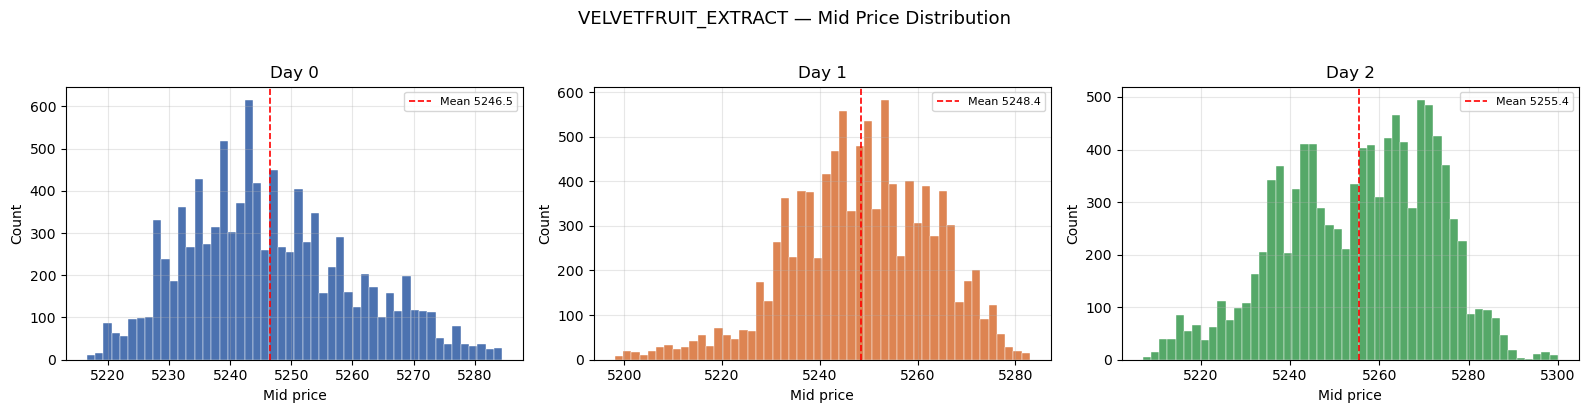

,mean,std,min,max
day,,,,
0,5246.51,13.68,5216.5,5284.5
1,5248.39,14.61,5198.0,5283.0
2,5255.39,16.99,5207.0,5300.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, d in zip(axes, days):
    sub = df[df["day"] == d]["mid_price"].dropna()
    ax.hist(sub, bins=50, color=day_colors[d], edgecolor="white", lw=0.3)
    ax.axvline(sub.mean(), color="red", ls="--", lw=1.2, label=f"Mean {sub.mean():.1f}")
    ax.set_title(day_labels[d]); ax.set_xlabel("Mid price"); ax.set_ylabel("Count")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.suptitle(f"{PRODUCT} — Mid Price Distribution", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
df.groupby("day")["mid_price"].agg(["mean","std","min","max"]).round(2)


## 4 — Order Book Depth (Best 3 Levels)

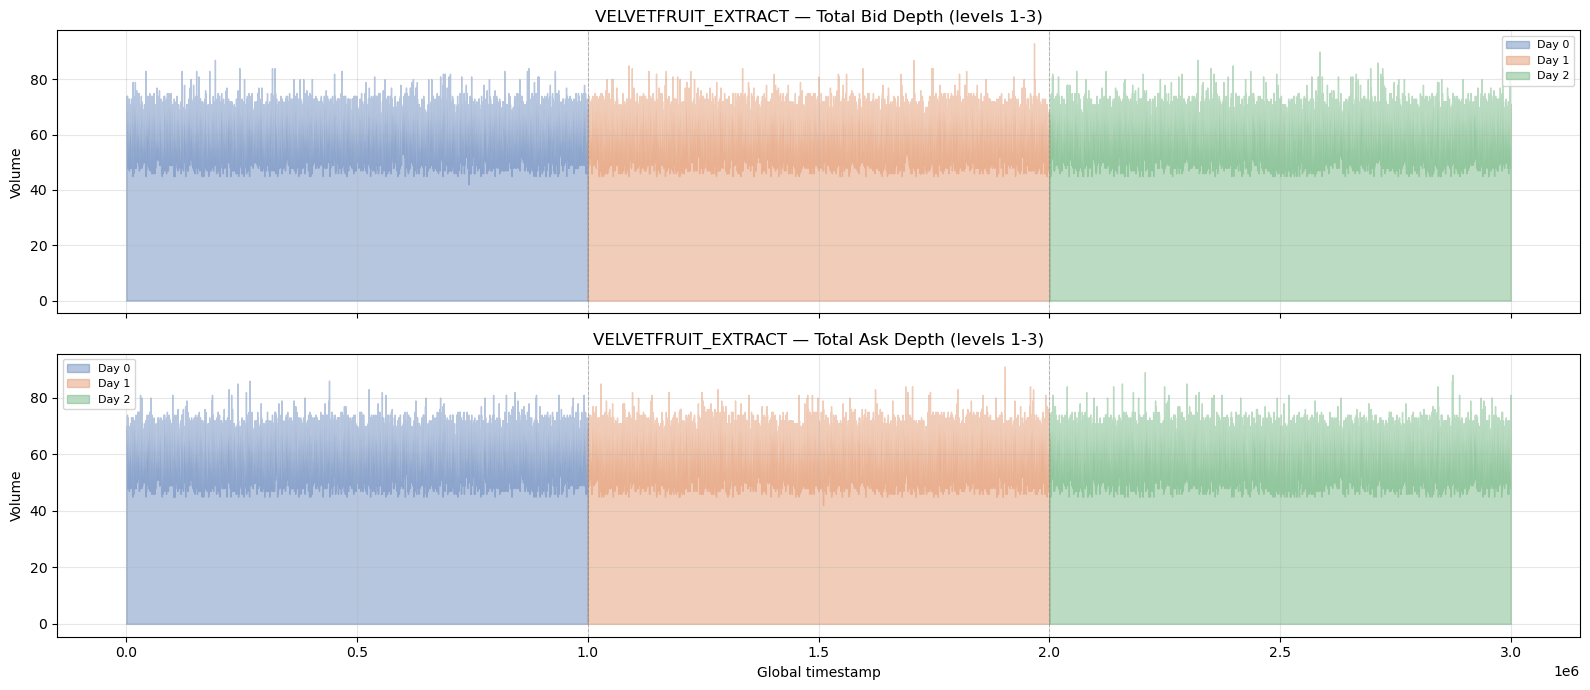

In [5]:
df["total_bid_vol"] = df[["bid_volume_1","bid_volume_2","bid_volume_3"]].fillna(0).sum(axis=1)
df["total_ask_vol"] = df[["ask_volume_1","ask_volume_2","ask_volume_3"]].fillna(0).abs().sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
for d in days:
    sub = df[df["day"] == d]
    axes[0].fill_between(sub["global_ts"], sub["total_bid_vol"],
                         alpha=0.4, color=day_colors[d], label=day_labels[d])
    axes[1].fill_between(sub["global_ts"], sub["total_ask_vol"],
                         alpha=0.4, color=day_colors[d], label=day_labels[d])
for ax in axes:
    for i in range(1, len(days)):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
axes[0].set_title(f"{PRODUCT} — Total Bid Depth (levels 1-3)"); axes[0].set_ylabel("Volume")
axes[1].set_title(f"{PRODUCT} — Total Ask Depth (levels 1-3)")
axes[1].set_ylabel("Volume"); axes[1].set_xlabel("Global timestamp")
plt.tight_layout(); plt.show()


## 5 — Price Returns & Volatility

/var/folders/cz/259j0kg12yvck75_4yxg72mr0000gn/T/ipykernel_7670/790202438.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()
/Users/pieterrotteveel/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


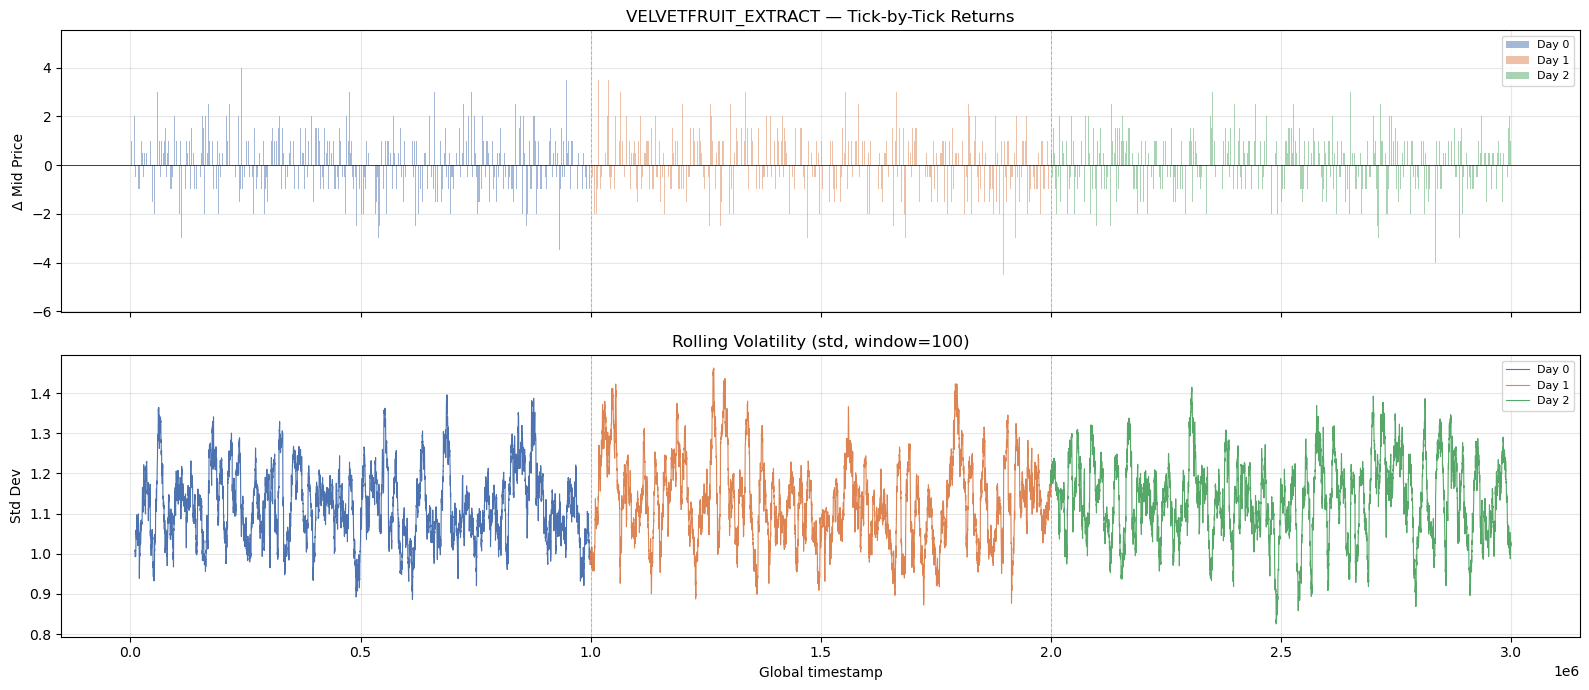

In [6]:
df["returns"]     = df["mid_price"].diff()
df["rolling_vol"] = df["returns"].rolling(100).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
for d in days:
    sub = df[df["day"] == d]
    ax1.bar(sub["global_ts"], sub["returns"], width=80, color=day_colors[d], alpha=0.5, label=day_labels[d])
    ax2.plot(sub["global_ts"], sub["rolling_vol"], color=day_colors[d], lw=0.8, label=day_labels[d])
for ax in (ax1, ax2):
    for i in range(1, len(days)):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
ax1.axhline(0, color="black", lw=0.5)
ax1.set_title(f"{PRODUCT} — Tick-by-Tick Returns"); ax1.set_ylabel("Δ Mid Price")
ax2.set_title("Rolling Volatility (std, window=100)"); ax2.set_ylabel("Std Dev")
ax2.set_xlabel("Global timestamp")
plt.tight_layout(); plt.show()


## 6 — Fair Value Estimation & Mean-Reversion Signal

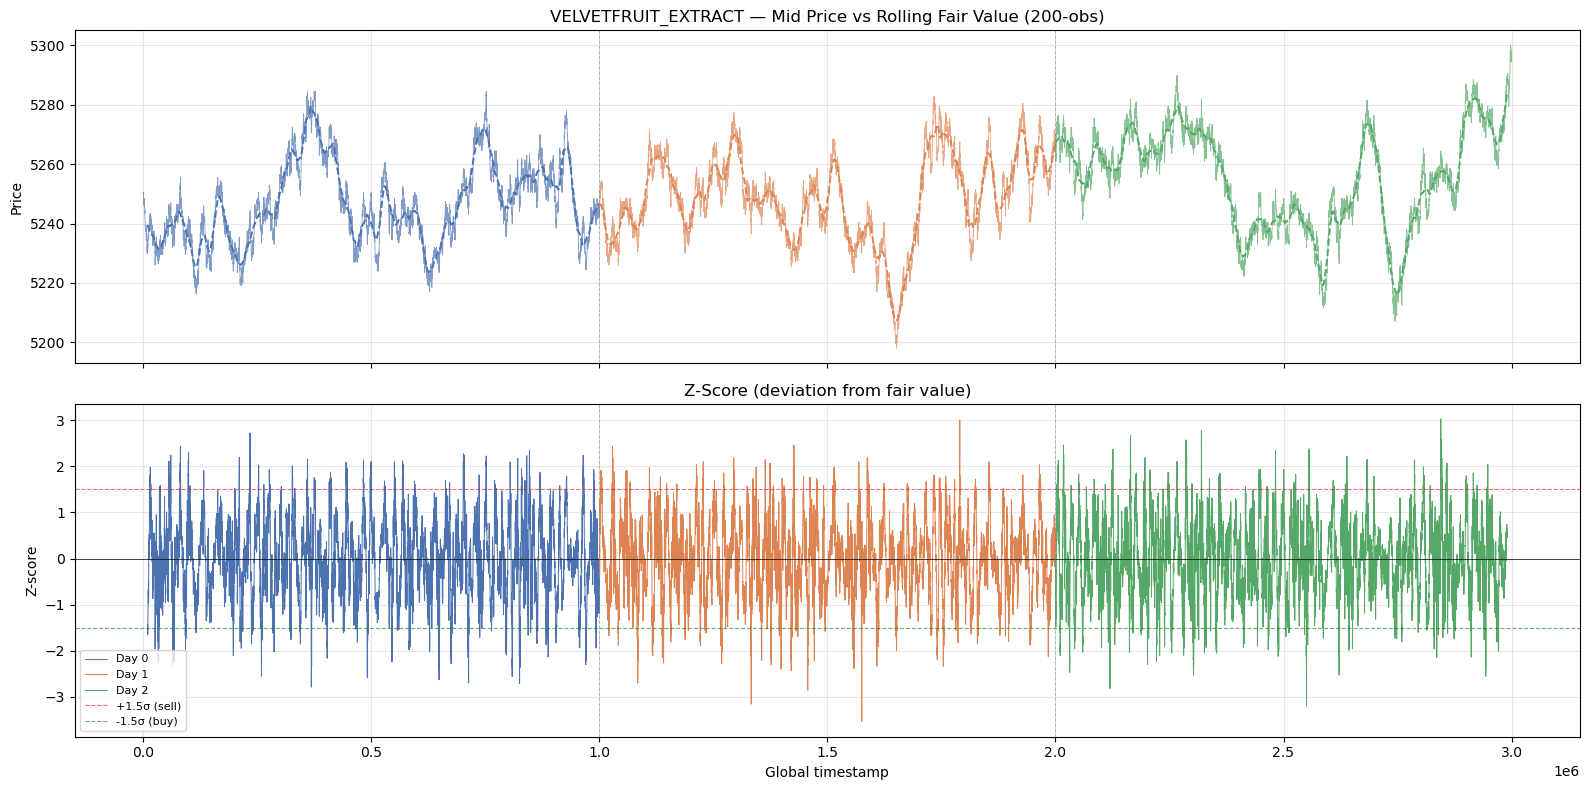

Overbought ticks (z>1.5): 1039  (3.5%)
Oversold   ticks (z<-1.5): 1110  (3.7%)


In [7]:
WINDOW = 200
df["fair_value"]  = df["mid_price"].rolling(WINDOW, center=True).mean()
df["fv_std"]      = df["mid_price"].rolling(WINDOW, center=True).std()
df["fv_zscore"]   = (df["mid_price"] - df["fair_value"]) / df["fv_std"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for d in days:
    sub = df[df["day"] == d]
    ax1.plot(sub["global_ts"], sub["mid_price"],  color=day_colors[d], lw=0.6, alpha=0.7)
    ax1.plot(sub["global_ts"], sub["fair_value"], color=day_colors[d], lw=1.4, ls="--")
    ax2.plot(sub["global_ts"], sub["fv_zscore"],  color=day_colors[d], lw=0.7, label=day_labels[d])
ax2.axhline( 1.5, color="red",   ls="--", lw=0.8, alpha=0.6, label="+1.5σ (sell)")
ax2.axhline(-1.5, color="green", ls="--", lw=0.8, alpha=0.6, label="-1.5σ (buy)")
ax2.axhline( 0,   color="black", lw=0.5)
for ax in (ax1, ax2):
    for i in range(1, len(days)):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.grid(True, alpha=0.3)
ax1.set_title(f"{PRODUCT} — Mid Price vs Rolling Fair Value ({WINDOW}-obs)"); ax1.set_ylabel("Price")
ax2.set_title("Z-Score (deviation from fair value)"); ax2.set_ylabel("Z-score")
ax2.set_xlabel("Global timestamp"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Signal stats
overbought = (df["fv_zscore"] > 1.5).sum()
oversold   = (df["fv_zscore"] < -1.5).sum()
print(f"Overbought ticks (z>1.5): {overbought}  ({100*overbought/len(df):.1f}%)")
print(f"Oversold   ticks (z<-1.5): {oversold}  ({100*oversold/len(df):.1f}%)")
